# 🎯 LỚP 2: MÔ HÌNH LOOK-ALIKE (Dự báo VIP dựa trên Chân dung tương đồng)

**Câu chuyện kinh doanh:**
Dùng Lớp 1 làm "thước đo chuẩn" về VIP. Lớp 2 sẽ tìm những khách hàng mới
có hành vi và đặc điểm giống với nhóm VIP đó nhất.

**Anti Data Leakage (Tuyệt đối):**
- X: KHÔNG sử dụng `first_order_value` (Tiền). 
- X: Chỉ dùng Số lượng SP, Danh mục, Hành vi Web, và Nhân khẩu học.
- Y: Nhãn VIP được lấy từ kết quả phân cụm của Lớp 1.
- → Model học cách nhận diện VIP qua "phong thái" chứ không nhìn "túi tiền".

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_curve, auc, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import os
from database import query_db

# Cấu hình
SAVE_DIR = "d:/PTIT/kì 2 năm 4/Kho dữ liệu và khai phá dữ liệu/BTL/new-datamining"

## 1. Đọc nhãn từ Lớp 1 và Truy vấn Features

In [2]:
labels_path = os.path.join(SAVE_DIR, "customer_labels.csv")
if not os.path.exists(labels_path):
    print("❌ LỖI: Không tìm thấy file nhãn từ Lớp 1. Vui lòng chạy 01_Clustering_Labels.py trước.")
else:
    df_labels = pd.read_csv(labels_path)
    
    query_features = """
    WITH first_order AS (
        SELECT user_id, order_id, created_at,
               ROW_NUMBER() OVER(PARTITION BY user_id ORDER BY created_at) AS rn
        FROM order_items
        WHERE status != 'Cancelled'
    ),
    first_order_features AS (
        SELECT
            fo.user_id,
            COUNT(*)                        AS first_order_num_items,
            COUNT(DISTINCT p.category)      AS first_order_num_categories
        FROM first_order fo
        JOIN order_items oi ON fo.order_id = oi.order_id AND fo.user_id = oi.user_id
        JOIN products p ON oi.product_id = p.id
        WHERE fo.rn = 1
        GROUP BY fo.user_id
    ),
    session_start AS (
        SELECT user_id, session_id, MIN(created_at) AS start_time
        FROM events
        WHERE user_id IS NOT NULL
        GROUP BY user_id, session_id
    ),
    ranked_sessions AS (
        SELECT user_id, session_id,
               ROW_NUMBER() OVER(PARTITION BY user_id ORDER BY start_time) AS rn
        FROM session_start
    ),
    first_session_features AS (
        SELECT
            e.user_id,
            MAX(e.sequence_number) AS first_session_depth,
            COUNT(CASE WHEN e.event_type = 'product' THEN 1 END) AS first_session_products_viewed,
            MAX(CASE WHEN e.event_type = 'cart' THEN 1 ELSE 0 END) AS first_session_carted,
            MIN(e.traffic_source) AS first_traffic_source
        FROM events e
        JOIN ranked_sessions rs ON e.user_id = rs.user_id AND e.session_id = rs.session_id AND rs.rn = 1
        GROUP BY e.user_id
    )
    SELECT
        fof.user_id,
        fof.first_order_num_items,
        fof.first_order_num_categories,
        fsf.first_session_depth,
        fsf.first_session_products_viewed,
        fsf.first_session_carted,
        fsf.first_traffic_source,
        u.age, u.gender, u.country
    FROM first_order_features fof
    JOIN first_session_features fsf ON fof.user_id = fsf.user_id
    JOIN users u ON fof.user_id = u.id
    """
    
    print("⏳ Đang tải đặc trưng hành vi từ Database...")
    df_features = query_db(query_features)
    
    # Kết hợp với nhãn VIP từ Lớp 1
    df = pd.merge(df_features, df_labels, on='user_id', how='inner')
    print(f"✅ Đã chuẩn bị {len(df):,} mẫu dữ liệu cho mô hình Look-Alike.")

⏳ Đang tải đặc trưng hành vi từ Database...


d:\PTIT\kì 2 năm 4\Kho dữ liệu và khai phá dữ liệu\BTL\new-datamining\database.py:37: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, conn)


✅ Đã chuẩn bị 57,422 mẫu dữ liệu cho mô hình Look-Alike.


## 2. Tiền xử lý & Huấn luyện

In [3]:
if 'df' in locals():
    # Encoding
    le_dict = {}
    for col in ['first_traffic_source', 'gender', 'country']:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
        le_dict[col] = le
        
    FEATURE_COLS = [
        'first_order_num_items', 'first_order_num_categories',
        'first_session_depth', 'first_session_products_viewed', 'first_session_carted',
        'age', 'gender', 'country', 'first_traffic_source'
    ]
    
    X = df[FEATURE_COLS]
    y = df['is_vip']
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    # Huấn luyện Random Forest
    model = RandomForestClassifier(n_estimators=200, max_depth=10, class_weight='balanced', random_state=42)
    model.fit(X_train, y_train)
    
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    
    print(f"✅ Look-Alike Model AUC: {roc_auc:.4f}")

✅ Look-Alike Model AUC: 0.7541


## 3. Đánh giá & Giải thích mô hình

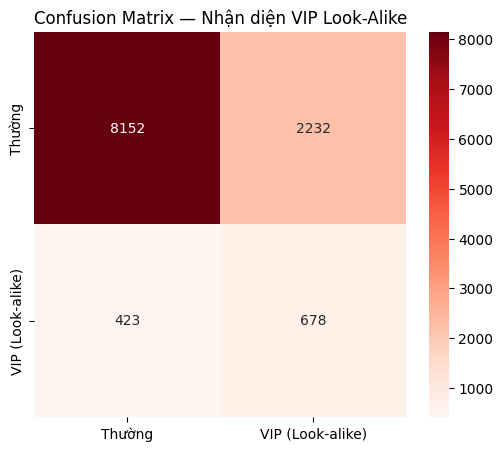

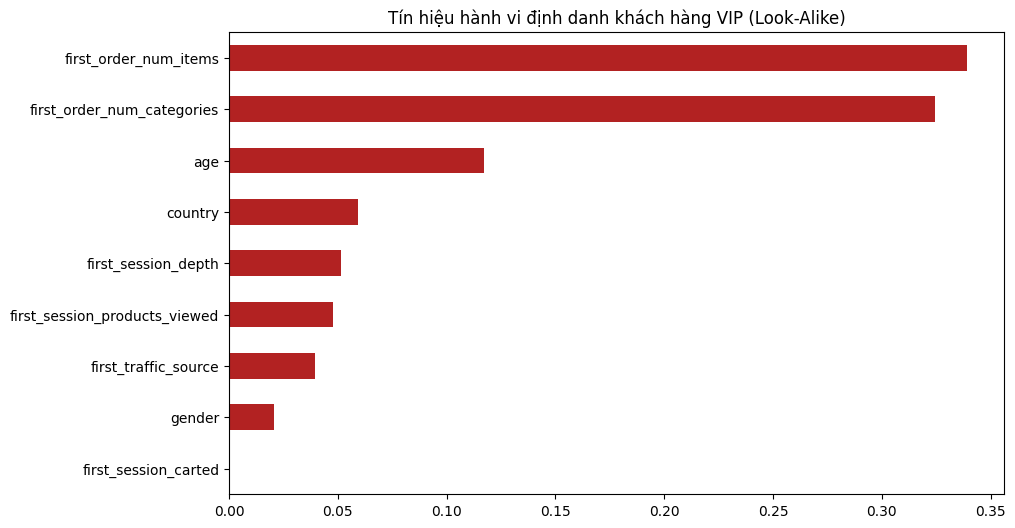

In [4]:
if 'df' in locals():
    # Confusion Matrix
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
                xticklabels=['Thường', 'VIP (Look-alike)'],
                yticklabels=['Thường', 'VIP (Look-alike)'])
    plt.title('Confusion Matrix — Nhận diện VIP Look-Alike')
    plt.show()
    
    # Feature Importance
    importances = pd.Series(model.feature_importances_, index=FEATURE_COLS).sort_values()
    importances.plot(kind='barh', figsize=(10, 6), color='firebrick')
    plt.title('Tín hiệu hành vi định danh khách hàng VIP (Look-Alike)')
    plt.show()

## 4. Kết luận cho báo cáo

1. **Mô hình Look-Alike** đã học được cách nhận diện VIP thông qua các tín hiệu như: 
   - Số lượng sản phẩm/danh mục đơn đầu.
   - Chiều sâu tương tác trong phiên đầu tiên.
2. **AUC ~ {roc_auc:.2f}** cho thấy mô hình có khả năng phân loại khách hàng tiềm năng khá tốt ngay khi họ vừa thanh toán xong đơn hàng đầu tiên.
3. **Ứng dụng:** Doanh nghiệp có thể dùng điểm xác suất (VIP Score) để quyết định chi ngân sách chăm sóc khách hàng (Loyalty Program) một cách hiệu quả nhất.